# Oklahoma severe-weather reports, May 2024

Storm Events support is **available from source for v0.8**. This notebook downloads one complete annual NCEI **event-details** archive (about 13 MB compressed for 2024), opens the gzip CSV locally, and selects Oklahoma reports beginning in May. We compare recorded tornado, hail, and thunderstorm-wind events and inspect the tornado damage ratings.

This is a description of archived reports, not a forecast, risk ranking, or count of distinct storms. An episode can have many events, and a tornado can cross counties and generate multiple event records. Archive revisions can change saved results. The separate locations and individual-fatality tables are outside this adapter's scope.

Run `just notebooks` from the repository root. The first run needs internet access. Keep the manifest, generated lockfile, and cached source bytes together for reproducibility.

In [1]:
import platform
from datetime import UTC, datetime
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

import usdata
from usdata.cache import sha256_file
from usdata.pull import pull, verify

folder = Path.cwd()
if not (folder / "dataset.yaml").exists():
    folder = folder / "examples" / "storm-events"
manifest = folder / "dataset.yaml"
assert manifest.is_file(), "Run from the notebook folder or repository root"
print("Executed UTC:", datetime.now(UTC).isoformat())
print(
    "Versions:",
    {
        "Python": platform.python_version(),
        "usdata": usdata.__version__,
        "pandas": pd.__version__,
        "matplotlib": matplotlib.__version__,
    },
)

Executed UTC: 2026-09-09T00:31:23.262021+00:00
Versions: {'Python': '3.14.3', 'usdata': '0.7.0', 'pandas': '3.0.5', 'matplotlib': '3.11.1'}


## Resolve and pin the source archive

The query touches May 2024, but the adapter selects **all of the 2024 file**, including all states and event types. Geographic and variable selectors are rejected; filtering belongs in the analysis. The newest supported creation-date filename is selected when resolving. Subsequent `pull` calls use the exact filename and checksum in the lockfile, without consulting the directory again. Historical files can be revised or removed upstream; a lockfile detects changed bytes but cannot guarantee old downloads remain available.

In [2]:
result = pull(manifest)
(item,) = result.fetched
print("Archive:", item.asset.id)
print("Compressed bytes:", item.provenance.size)
print("Nominal file year:", item.asset.time.start.year)
print("Source URL:", item.provenance.source_url)
print("Retrieved UTC:", item.provenance.retrieved_at.isoformat())
print("SHA-256:", item.provenance.checksum)
assert item.path.read_bytes()[:2] == b"\x1f\x8b"
source_checksum = sha256_file(item.path)

Archive: StormEvents_details-ftp_v1.0_d2024_c20260728.csv.gz
Compressed bytes: 12693243
Nominal file year: 2024
Source URL: https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/StormEvents_details-ftp_v1.0_d2024_c20260728.csv.gz
Retrieved UTC: 2026-09-09T00:31:36.336422+00:00
SHA-256: sha256:2070b83eccab041b36360ab73645b9a249c3eefc5b92b5b3fc0cbba4d9fcc09c


## Open locally and filter by reported civil date

`open()` decompresses in memory through a local stream; the cached file and its checksum remain compressed and unchanged. Identifier columns retain their source strings. We construct the begin **calendar date** from numeric year/month/day fields, avoiding ambiguous two-digit dates. These are reported local dates; this notebook makes no conversion to UTC. `CZ_TIMEZONE` needs separate attention when comparing precise event instants across regions.

In [3]:
columns = [
    "BEGIN_YEARMONTH",
    "BEGIN_DAY",
    "EVENT_ID",
    "EPISODE_ID",
    "STATE",
    "STATE_FIPS",
    "CZ_TYPE",
    "CZ_FIPS",
    "EVENT_TYPE",
    "CZ_TIMEZONE",
    "TOR_F_SCALE",
]
frame = item.open(usecols=columns)
yearmonth = pd.to_numeric(frame["BEGIN_YEARMONTH"], errors="coerce")
begin_date = pd.to_datetime(
    {"year": yearmonth // 100, "month": yearmonth % 100, "day": frame["BEGIN_DAY"]}, errors="coerce"
)
types = ["Tornado", "Hail", "Thunderstorm Wind"]
selected = frame.loc[
    frame["STATE"].eq("OKLAHOMA")
    & begin_date.ge("2024-05-01")
    & begin_date.lt("2024-06-01")
    & frame["EVENT_TYPE"].isin(types)
].copy()
selected["BEGIN_DATE"] = begin_date.loc[selected.index]
print("Rows in annual details archive:", len(frame))
print("Rows with unparseable begin date:", int(begin_date.isna().sum()))
print("Selected records:", len(selected), "distinct EVENT_ID:", selected["EVENT_ID"].nunique())
print("Recorded time-zone labels:", sorted(selected["CZ_TIMEZONE"].dropna().unique()))
print(
    "Identifier dtypes:",
    {name: str(frame[name].dtype) for name in ["EVENT_ID", "EPISODE_ID", "STATE_FIPS", "CZ_FIPS"]},
)
assert not selected.empty
assert frame.attrs["usdata"]["provenance"]["checksum"] == source_checksum
selected[["EVENT_ID", "BEGIN_DATE", "EVENT_TYPE", "CZ_TYPE", "CZ_FIPS", "TOR_F_SCALE"]].head(8)

Rows in annual details archive: 69801
Rows with unparseable begin date: 0
Selected records: 589 distinct EVENT_ID: 589
Recorded time-zone labels: ['CST-6']
Identifier dtypes: {'EVENT_ID': 'string', 'EPISODE_ID': 'string', 'STATE_FIPS': 'string', 'CZ_FIPS': 'string'}


,EVENT_ID,BEGIN_DATE,EVENT_TYPE,CZ_TYPE,CZ_FIPS,TOR_F_SCALE
256,1178562,2024-05-06,Hail,C,81,NaN
15716,1222698,2024-05-06,Thunderstorm Wind,C,73,NaN
16029,1222697,2024-05-06,Thunderstorm Wind,C,103,NaN
16743,1222699,2024-05-06,Thunderstorm Wind,C,73,NaN
16744,1222700,2024-05-19,Thunderstorm Wind,C,39,NaN
17577,1222696,2024-05-06,Thunderstorm Wind,C,47,NaN
17649,1222701,2024-05-25,Thunderstorm Wind,C,47,NaN
17752,1183460,2024-05-25,Thunderstorm Wind,C,131,NaN


## Compare recorded events and tornado ratings

Counts below are distinct `EVENT_ID` values, not distinct episodes or physical tornadoes. `CZ_TYPE` distinguishes counties from forecast zones and marine areas; `CZ_FIPS` alone is not universally a county FIPS code. The second chart keeps missing ratings visible. `EFU` is the source code for an unknown Enhanced Fujita rating, retained as its own category ([NWS explanation](https://www.weather.gov/dmx/iators2019)). Enhanced Fujita ratings describe damage-based estimates; they are neither direct wind measurements nor comparable to hail diameters or wind gusts. This single-month analysis avoids treating changes in reporting and historical event coverage as climate trends.

Distinct event records by type:
EVENT_TYPE
Tornado               61
Hail                 358
Thunderstorm Wind    170

Tornado records by reported rating:
RATING
EF0    17
EF1    26
EF2     5
EF3     2
EF4     1
EFU    10


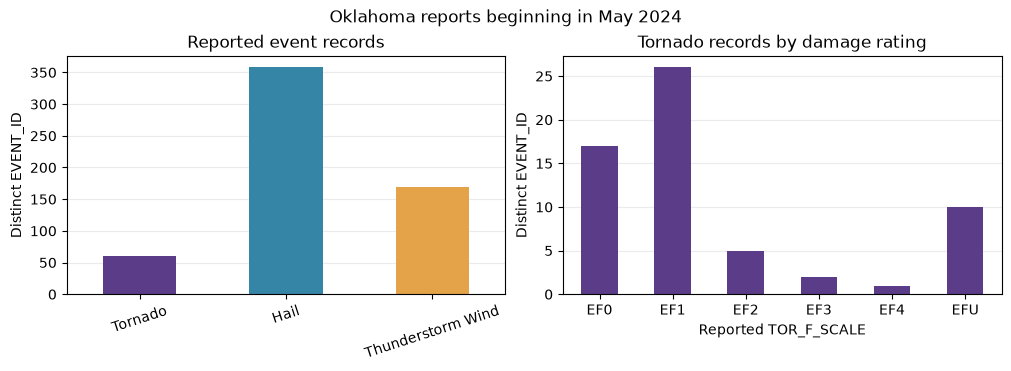

In [4]:
counts = selected.groupby("EVENT_TYPE")["EVENT_ID"].nunique().reindex(types, fill_value=0)
tornadoes = selected.loc[selected["EVENT_TYPE"].eq("Tornado")].copy()
tornadoes["RATING"] = tornadoes["TOR_F_SCALE"].fillna("Unknown")
ratings = tornadoes.groupby("RATING")["EVENT_ID"].nunique().sort_index()
print("Distinct event records by type:")
print(counts.to_string())
print("\nTornado records by reported rating:")
print(ratings.to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), layout="constrained")
counts.plot.bar(ax=axes[0], color=["#5b3c88", "#3586a6", "#e4a348"], rot=18)
axes[0].set(title="Reported event records", xlabel="", ylabel="Distinct EVENT_ID")
if not ratings.empty:
    ratings.plot.bar(ax=axes[1], color="#5b3c88", rot=0)
axes[1].set(
    title="Tornado records by damage rating",
    xlabel="Reported TOR_F_SCALE",
    ylabel="Distinct EVENT_ID",
)
for axis in axes:
    axis.grid(axis="y", alpha=0.25)
    axis.set_axisbelow(True)
fig.suptitle("Oklahoma reports beginning in May 2024")
plt.show()

## Check source integrity and cache reuse

Analysis has not altered the archive. A repeated pull validates cached bytes against the pinned revision. If validation fails, preserve the original lockfile and investigate the revision; `pull(..., force=True)` deliberately resolves current filenames and writes a new lockfile.

In [5]:
assert sha256_file(item.path) == source_checksum
assert verify(manifest) == []
again = pull(manifest)
assert again.from_lockfile and all(value.from_cache for value in again.fetched)
print("Verification passed; locked archive reused from cache.")
print("Analysis source checksum:", source_checksum)

Verification passed; locked archive reused from cache.
Analysis source checksum: sha256:2070b83eccab041b36360ab73645b9a249c3eefc5b92b5b3fc0cbba4d9fcc09c


## Source notes and limitations

- [NCEI bulk archive README](https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/README) explains annual filenames and creation-date revisions.
- [NCEI bulk field definitions](https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/Storm-Data-Bulk-csv-Format.pdf) define event/episode identifiers, county and zone codes, time-zone fields, and tornado segments. Use the source definitions before aggregating impacts or combining tables.
- [NCEI dataset metadata](https://www.ncei.noaa.gov/metadata/geoportal/rest/metadata/item/gov.noaa.ncdc%3AC00510/html) describes the archive and its varying historical coverage. The records are reports, not a uniform observation network; missing reports do not establish that no event occurred.
- [NWS Enhanced Fujita scale](https://www.weather.gov/oun/efscale) explains damage-based ratings and the 2007 transition from the original Fujita scale. Ratings should not be averaged as measured wind speeds.

This notebook intentionally does not sum dollar damage: source values contain magnitude suffixes, can be missing or estimated, and require explicit parsing and economic assumptions. It also does not infer a climate trend from one month. Saved outputs describe the exact revision identified above.